# De Novo Design of Potential CCR2 Binders with DrugEx and ROCS Shape-Based Scoring

 This tutorial demonstrates the use of DrugEx with shape-based scoring using ROCS (Rapid Overlay of Chemical Structures).
* We will fine-tune a pretrained RNN model on CCR2 ligand data and then use reinforcement learning with shape-based 
* similarity objectives (using RDKit, CDPKit, or OpenEye implementations) combined with synthetic accessibility (SA) scores.


In [2]:

import torch

# Check if CUDA is available (optional, can run on CPU as well)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch version: 2.5.1+cu124
CUDA available: True


In [3]:
# ==============================================================================
# Configuration: toggle (re)training steps
# ==============================================================================
RERUN_FINETUNE = False  # set True to retrain the transfer learning step
RERUN_RL_RDKIT = True  # set True to rerun RDKit-based RL training
RERUN_RL_CDPKIT = True  # set True to rerun CDPKit-based RL training
RERUN_RL_CLI = True     # set True to rerun OpenEye CLI-based RL training

FINETUNE_EPOCHS = 100
RL_EPOCHS = 15
RL_EPSILON = 0.1
RL_N_SAMPLES = 2000


# ROCS-Based RNN for CCR2 Ligand Design

This notebook demonstrates the application of DrugEx with shape-based scoring for designing potential CCR2 (C-C Chemokine Receptor 2) ligands. We compare three ROCS implementations (RDKit, CDPKit, and OpenEye) for 3D molecular similarity scoring.

## Workflow Overview

1. **Data Loading**: Import CCR2 ligand bioactivity data and standardize SMILES
2. **Data Encoding**: Encode molecules using pretrained vocabulary and split into train/test sets
3. **Fine-Tuning**: Transfer learning from general pretrained model to CCR2-specific model
4. **Scoring Setup**: Configure ROCS shape similarity and synthetic accessibility objectives
5. **Reinforcement Learning**: Train models to optimize both objectives using Pareto optimization
6. **Generation**: Generate novel molecules and evaluate performance across backends

## Imports and Paths

In [4]:
import os
from pathlib import Path
import shutil
import time
import warnings

import numpy as np
import pandas as pd
import torch

from drugex.data.corpus.vocabulary import VocSmiles
from drugex.training.generators import SequenceRNN
from drugex.training.monitors import FileMonitor
from drugex.training.explorers import SequenceExplorer
from drugex.training.environment import DrugExEnvironment
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.scorers.properties import Property
from drugex.training.scorers.conformer_generators import RDKitConformerGenerator
from drugex.logs import logger

# # Suppress warnings for cleaner output
# warnings.filterwarnings('ignore')
# logger.setLevel('ERROR')

try:
    from drugex.training.scorers.conformer_generators import CDPKitConformerGenerator
    from drugex.training.scorers.cdpkit_rocs import CDPKitROCSScorer
    CDPKIT_READY = True
except ImportError:
    CDPKitConformerGenerator = None
    CDPKitROCSScorer = None
    CDPKIT_READY = False

try:
    from drugex.training.scorers.conformer_generators import OmegaConformerGenerator
    from drugex.training.scorers.cli_rocs import CLIROCSScorer
    OPENEYE_READY = True
except ImportError:
    OmegaConformerGenerator = None
    CLIROCSScorer = None
    OPENEYE_READY = False

from drugex.training.scorers.rdkit_rocs import RDKitROCSScorer

# Set random seeds for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Define paths
ROOT = Path.cwd()
RES = ROOT / 'rocs_rl_ccr/rdkit_cdpkit'
CCR2_TSV = RES / 'CCR_HUMAN_AL.tsv'
CCR2_SDF = RES / 'CCR2_reference_ligands.sdf'
MODEL_DIR = ROOT / 'demo_out/models'
RUN_DIR = ROOT / 'rl_runs_demo'
DATA_DIR = ROOT / 'demo_out/datasets/encoded/rnn/'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
ROCS_BINARY = shutil.which('rocs') if OPENEYE_READY else None

# Path to pretrained model
MODELS_PR_PATH = "../data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT/"

# Training parameters
N_PROCESSES = 20  # number of CPU cores to use
CHUNK_SIZE = 1000  # largest chunk per CPU core (regulates RAM usage)
BATCH_SIZE = 256  # batch size for training

print(f"CCR2 data: {CCR2_TSV.exists()}")
print(f"CCR2 reference SDF: {CCR2_SDF.exists()}")
print(f"Pretrained model path: {Path(MODELS_PR_PATH).exists()}")
print(f"CDPKit available: {CDPKIT_READY}")
print(f"OpenEye available: {OPENEYE_READY and ROCS_BINARY is not None}")

# Helper paths and utilities
FINETUNE_BASE = MODEL_DIR / 'CCR2_finetuned'
FINETUNE_CHECKPOINT = Path(f"{FINETUNE_BASE}.pkg")
FINETUNE_VOCAB = Path(f"{FINETUNE_BASE}.vocab")
FINETUNE_FIT_FILE = Path(f"{FINETUNE_BASE}_fit.tsv")

RL_OUTPUT_DIRS = {
    'rdkit': RUN_DIR / 'rdkit_rl',
    'cdpkit': RUN_DIR / 'cdpkit_rl',
    'cli': RUN_DIR / 'cli_rl',
}

def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)

def rl_paths(name: str) -> dict:
    out_dir = RL_OUTPUT_DIRS[name]
    ensure_dir(out_dir)
    base = out_dir / f"CCR2_{name}_reinforced"
    return {
        'output_dir': out_dir,
        'base': base,
        'checkpoint': Path(f"{base}.pkg"),
        'fit_file': Path(f"{base}_fit.tsv"),
        'smiles_file': Path(f"{base}_smiles.tsv"),
        'log_file': Path(f"{base}_fit.log"),
    }

def rl_artifacts_exist(paths: dict) -> bool:
    required = ('checkpoint', 'fit_file')
    if not all(paths[key].exists() for key in required):
        return False
    smiles_path = paths.get('smiles_file')
    return smiles_path.exists() if smiles_path is not None else True

def print_existing_summary(tsv_path: Path, tail: int = 5) -> None:
    if not tsv_path.exists():
        print(f" - No training history found at {tsv_path}")
        return
    df_hist = pd.read_csv(tsv_path, sep='\t')
    preferred: list[str] = []
    if 'epoch' in df_hist.columns:
        preferred.append('epoch')
    for optional in ('desired_ratio', 'avg_amean'):
        if optional in df_hist.columns:
            preferred.append(optional)
    cols = preferred if preferred else df_hist.columns.tolist()
    last = min(tail, len(df_hist))
    print(f"\nExisting training metrics ({tsv_path.name}, last {last} epochs):")
    print(df_hist[cols].tail(tail))


CCR2 data: True
CCR2 reference SDF: True
Pretrained model path: True
CDPKit available: True
OpenEye available: True


## Loading and Preparing CCR2 Ligand Data

We start by loading CCR2 ligand data and standardizing the SMILES strings using DrugEx's standardization pipeline.

In [5]:
from drugex.data.processing import Standardization

# Load CCR2 ligand data
df_ccr2 = pd.read_table(CCR2_TSV)
print(f"Loaded {len(df_ccr2)} CCR2 ligands")

# Standardize SMILES strings
standardizer = Standardization(n_proc=N_PROCESSES, chunk_size=CHUNK_SIZE)
smiles_ft = standardizer.apply(df_ccr2.SMILES)
print(f"Standardized {len(smiles_ft)} SMILES")
smiles_ft[0:10]

Loaded 1021 CCR2 ligands


Standardizing molecules (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Standardized 1021 SMILES


['COc1nc(Br)cnc1NS(=O)(=O)c1sc(Cl)cc1Br',
 'COc1nc(Br)cnc1NS(=O)(=O)c1cc(Cl)c(Cl)s1',
 'COc1nc(Cl)cnc1NS(=O)(=O)c1scc(Cl)c1Cl',
 'COc1nc(Cl)c(Cl)nc1NS(=O)(=O)c1ccc(Cl)s1',
 'CSc1nc(Br)cnc1NS(=O)(=O)c1ccc(Cl)s1',
 'COc1nc(Br)cnc1NS(=O)(=O)c1ccc(Cl)s1',
 'COc1nc(Br)cnc1NS(=O)(=O)c1ccc(Cl)s1',
 'COc1nccnc1NS(=O)(=O)c1scc(Cl)c1Cl',
 'CNc1nc(Br)cnc1NS(=O)(=O)c1ccc(Cl)s1',
 'COc1nc(Br)cnc1NS(=O)(=O)c1ccsc1']

In [6]:
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.datasets import SmilesDataSet

# Load vocabulary from pretrained model
voc = VocSmiles.fromFile(f"{MODELS_PR_PATH}/Papyrus05.5_smiles_rnn_PT.vocab", encode_frags=False)

# Encode SMILES data using the vocabulary
encoder = CorpusEncoder(
    SequenceCorpus,  # The corpus class implements how each SMILES string is divided into tokens
    {
        'vocabulary': voc,  # use pretrained vocabulary
        'update_voc': False,  # keep vocabulary fixed (no new tokens added)
        'throw': True  # discard compounds containing unknown tokens
    },
    n_proc=N_PROCESSES,
    chunk_size=CHUNK_SIZE
)

# Collect encoded data
data_collector = SmilesDataSet(os.path.join(DATA_DIR, 'ccr2_ligand_corpus.tsv'), rewrite=True)
encoder.apply(smiles_ft, collector=data_collector)
print(f"Encoded {len(data_collector.getData())} molecules")

# Split into train/test sets
splitter = RandomTrainTestSplitter(0.05, 1e4)
train, test = splitter(data_collector.getData())

# Create train and test datasets
for data, name in zip([train, test], ['train', 'test']):
    file_path = os.path.join(DATA_DIR, f'ccr2_{name}.tsv')
    pd.DataFrame(data).to_csv(file_path, header=True, index=False, sep='\t')
    print(f"Saved {len(data)} molecules to {name} set")

# Create data loaders
data_set_train = SmilesDataSet(os.path.join(DATA_DIR, 'ccr2_train.tsv'), voc=voc)
data_set_test = SmilesDataSet(os.path.join(DATA_DIR, 'ccr2_test.tsv'), voc=voc)
loader_train = data_set_train.asDataLoader(batch_size=BATCH_SIZE)
loader_test = data_set_test.asDataLoader(batch_size=BATCH_SIZE)

print(f"\nTrain batches: {len(loader_train)}, Test batches: {len(loader_test)}")

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Molecule does not meet min/max words requirements (min: 10, max: 100). Words found: {'L', '(', 'S', 'c', 'F', '1', '3', '2', 'N', 'C', 'O', '=', ')', 'EOS'} (occurrence count: 102). It will be ignored.


Encoded 879 molecules
Saved 835 molecules to train set
Saved 44 molecules to test set

Train batches: 4, Test batches: 1


## Fine-Tuning with Transfer Learning

We fine-tune the pretrained Papyrus model on our CCR2-specific data using transfer learning. This allows the model to learn CCR2-relevant chemical space while retaining general chemical knowledge.

In [7]:
# Check if we should skip fine-tuning
finetune_checkpoint = FINETUNE_CHECKPOINT
vocab_checkpoint = FINETUNE_VOCAB
fit_report = FINETUNE_FIT_FILE

finetune_exists = (
    finetune_checkpoint.exists() and
    vocab_checkpoint.exists()
)

skip_finetuning = finetune_exists and not RERUN_FINETUNE

if skip_finetuning:
    print("=" * 60)
    print("USING EXISTING FINE-TUNED MODEL")
    print("=" * 60)
    print(f"Loading from: {finetune_checkpoint}")

    # Load vocabulary for downstream scoring
    voc = VocSmiles.fromFile(str(vocab_checkpoint), encode_frags=False)
    print("Vocabulary loaded successfully")
else:
    print("=" * 60)
    print("TRAINING NEW FINE-TUNED MODEL")
    print("=" * 60)

    ensure_dir(MODEL_DIR)
    finetuned = SequenceRNN(voc, is_lstm=True)
    finetuned.loadStatesFromFile(os.path.join(MODELS_PR_PATH, 'Papyrus05.5_smiles_rnn_PT.pkg'))

    monitor = FileMonitor(str(FINETUNE_BASE), save_smiles=True, reset_directory=True)

    start = time.time()
    finetuned.fit(loader_train, loader_test, epochs=FINETUNE_EPOCHS, monitor=monitor, patience=30)
    monitor.close()

    torch.save(finetuned.getModel(), str(finetune_checkpoint))
    voc.toFile(str(vocab_checkpoint))

    print(f'\nFine-tuning completed in {time.time() - start:.1f}s')
    print(f'Model saved to: {finetune_checkpoint}')


USING EXISTING FINE-TUNED MODEL
Loading from: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/demo_out/models/CCR2_finetuned.pkg
Vocabulary loaded successfully



Existing model training metrics (last 5 epochs):
    Epoch  loss_train  loss_valid  valid_ratio  best_epoch
76     77       0.072       0.151        0.959          50
77     78       0.072       0.151        0.953          50
78     79       0.073       0.151        0.953          50
79     80       0.072       0.150        0.957          50
80     81       0.073       0.150        0.953          50


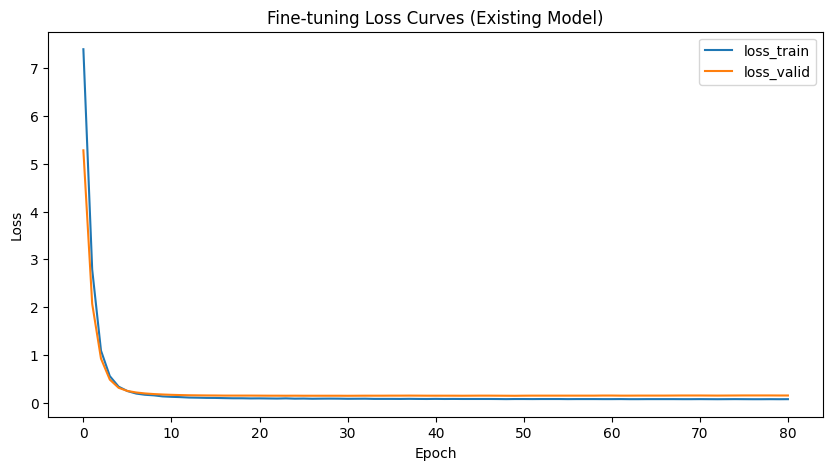

In [8]:
# Visualize training progress
if not skip_finetuning:
    df_ft_info = pd.read_csv(f'{MODEL_DIR}/CCR2_finetuned_fit.tsv', sep='\t')
    print("\nTraining metrics (last 5 epochs):")
    print(df_ft_info.tail())
    
    # Plot training curves
    df_ft_info[['loss_train', 'loss_valid']].plot.line(
        title='Fine-tuning Loss Curves',
        xlabel='Epoch',
        ylabel='Loss',
        figsize=(10, 5)
    )
else:
    # Load existing training data if available
    fit_file = f'{MODEL_DIR}/CCR2_finetuned_fit.tsv'
    if os.path.exists(fit_file):
        df_ft_info = pd.read_csv(fit_file, sep='\t')
        print("\nExisting model training metrics (last 5 epochs):")
        print(df_ft_info.tail())
        
        # Plot training curves
        df_ft_info[['loss_train', 'loss_valid']].plot.line(
            title='Fine-tuning Loss Curves (Existing Model)',
            xlabel='Epoch',
            ylabel='Loss',
            figsize=(10, 5)
        )
    else:
        print("Note: Fine-tuning history not available for visualization")


## Defining Scoring Functions and RL Environments

We define scoring functions for our reinforcement learning objectives:
1. **Shape-based similarity (ROCS)**: Measures 3D shape and pharmacophore similarity to known CCR2 ligands
2. **Synthetic Accessibility (SA)**: Favors molecules that are easier to synthesize (lower SA scores are better)

We configure three different ROCS implementations for comparison:
- **RDKit**: Open-source
- **CDPKit**: Open-source
- **OpenEye CLI**: Commercial

In [9]:
def sa_scorer():
    """Create synthetic accessibility scorer with smooth clipping"""
    sa = Property('SA')
    sa.setModifier(SmoothClippedScore(lower_x=5, upper_x=3))
    return sa


def env_rdkit():
    """Create environment with RDKit ROCS scorer"""
    scorer = RDKitROCSScorer(
        conformer_generator=RDKitConformerGenerator(
            max_conformers=30,
            max_isomers=2,
            max_heavy_atoms=30,
            show_progress=True,
        ),
        references=str(CCR2_SDF),
        score_type='TanimotoCombo',
        use_colors=True,
        show_progress=True,
        n_jobs=-1,
    )
    env = DrugExEnvironment([scorer, sa_scorer()], [0.8, 0.1], ParetoCrowdingDistance())
    return scorer, env


def env_cdpkit():
    """Create environment with CDPKit ROCS scorer"""
    if not CDPKIT_READY:
        raise RuntimeError('CDPKit bindings not available')
    scorer = CDPKitROCSScorer(
        conformer_generator=CDPKitConformerGenerator(
            max_conformers=30,
            max_isomers=2,
            max_heavy_atoms=30,
            show_progress=True,
        ),
        references=str(CCR2_SDF),
        show_progress=True,
        n_jobs=-1,
    )
    env = DrugExEnvironment([scorer, sa_scorer()], [0.9, 0.1], ParetoCrowdingDistance())
    return scorer, env


def env_cli():
    """Create environment with OpenEye CLI ROCS scorer"""
    if not (OPENEYE_READY and ROCS_BINARY):
        raise RuntimeError('OpenEye ROCS CLI not available')
    scorer = CLIROCSScorer(
        conformer_generator=OmegaConformerGenerator(
            max_conformers=30,
            max_centers=2,
            max_heavy_atoms=30,
            use_gpu=False,
            show_progress=True,
        ),
        query_files={'CCR2': str(CCR2_SDF)},
        score_type='TanimotoCombo',
        shape_only=False,
        optimize=True,
        color_optimize=True,
        rocs_binary=ROCS_BINARY,
        show_progress=True,
    )
    env = DrugExEnvironment([scorer, sa_scorer()], [0.9, 0.1], ParetoCrowdingDistance())
    return scorer, env


ENV_BUILDERS = {'rdkit': env_rdkit}
if CDPKIT_READY:
    ENV_BUILDERS['cdpkit'] = env_cdpkit
if OPENEYE_READY and ROCS_BINARY:
    ENV_BUILDERS['cli'] = env_cli

print(f"Available backends: {list(ENV_BUILDERS.keys())}")
backend_rows = [
    {'backend': name, 'output_dir': str(RL_OUTPUT_DIRS[name])}
    for name in ENV_BUILDERS
]
pd.DataFrame(backend_rows)


Available backends: ['rdkit', 'cdpkit', 'cli']


,backend,output_dir
0,rdkit,/home/dodo/Documents/projects/drugex-rocs/Drug...
1,cdpkit,/home/dodo/Documents/projects/drugex-rocs/Drug...
2,cli,/home/dodo/Documents/projects/drugex-rocs/Drug...


## Reinforcement Learning with Multi-Objective Optimization

We now train our model using reinforcement learning to optimize for both shape similarity and synthetic accessibility simultaneously. The RL process uses:
- **Agent (exploitation network)**: Starts from pretrained model, gets trained
- **Mutate (exploration network)**: Finetuned model, provides diversity via epsilon-greedy sampling
- **Epsilon**: Controls exploration rate (0.4 = 40% tokens from finetuned model)
- **Pareto optimization**: Balances multiple objectives without requiring manual weighting

Each backend (RDKit, CDPKit, OpenEye) will be trained separately to allow comparison.

In [10]:
# Shared container for reinforcement-learning runs
rl_runs = []

def record_run(backend, paths, elapsed=None):
    entry = {
        'backend': backend,
        'fit_path': str(paths['fit_file']),
        'checkpoint': str(paths['checkpoint']),
        'base_prefix': str(paths['base']),
        'output_dir': str(paths['output_dir']),
        'smiles_path': str(paths['smiles_file']),
    }
    if elapsed is not None:
        entry['elapsed_s'] = round(float(elapsed), 1)
    rl_runs.append(entry)

print('RL run registry initialised. Execute individual backend cells as needed.')


RL run registry initialised. Execute individual backend cells as needed.


In [10]:
# Reinforcement learning with RDKit ROCS
paths = rl_paths('rdkit')
artifacts_present = rl_artifacts_exist(paths)

if RERUN_RL_RDKIT or not artifacts_present:
    print('=' * 60)
    print('Backend: RDKit')
    print('=' * 60)
    if artifacts_present and RERUN_RL_RDKIT:
        print('Overwriting existing RDKit artifacts...')

    if not FINETUNE_CHECKPOINT.exists():
        raise FileNotFoundError(f'Fine-tuned checkpoint missing: {FINETUNE_CHECKPOINT}')

    scorer, env = env_rdkit()

    agent = SequenceRNN(voc, is_lstm=True)
    agent.loadStatesFromFile(os.path.join(MODELS_PR_PATH, 'Papyrus05.5_smiles_rnn_PT.pkg'))

    mutate = SequenceRNN(voc, is_lstm=True)
    mutate.loadStatesFromFile(str(FINETUNE_CHECKPOINT))

    explorer = SequenceExplorer(
        agent=agent,
        env=env,
        mutate=mutate,
        epsilon=RL_EPSILON,
        n_samples=RL_N_SAMPLES,
    )

    monitor = FileMonitor(str(paths['base']), save_smiles=True, reset_directory=True)
    start = time.time()
    explorer.fit(monitor=monitor, epochs=RL_EPOCHS)
    monitor.close()

    elapsed = time.time() - start
    print(f"RDKit RL training completed in {elapsed:.1f}s")
    record_run('rdkit', paths, elapsed)
else:
    print('=' * 60)
    print('Backend: RDKit (reuse)')
    print('=' * 60)
    print(f"Artifacts found in {paths['output_dir']}")
    print_existing_summary(paths['fit_file'])
    record_run('rdkit', paths)


Backend: RDKit


Removing CCR2_rdkit_reinforced_fit.log from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rl_runs_demo/rdkit_rl
Removing CCR2_rdkit_reinforced.pkg from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rl_runs_demo/rdkit_rl


Fitting SMILES RNN explorer:   0%|          | 0/15 [00:00<?, ?it/s]

Skipping Cc1c(-c2ccccc2)n(Cc2ccc(OCCN3CCCCC3C)cc2)c2ccccc12 with > 30 heavy atoms


Scoring 2000 molecules with ['RDKit_Aggregate_5refs_TanimotoCombo']...


...

Scoring complete. Average score: 0.818


Calculating policy gradient...:   0%|          | 0/15 [00:00<?, ?it/s]

Scoring 200 molecules with ['RDKit_Aggregate_5refs_TanimotoCombo']...


Skipping CN(Cc1ccccc1)c1ccc(C(=O)c2cccc(C(=O)c3ccc(Cl)cc3)c2)cc1 with > 30 heavy atoms
Scoring unique molecules: 100%|██████████| 191/191 [00:01<00:00, 135.13it/s]


Scoring complete. Average score: 0.856
RDKit RL training completed in 4244.7s


In [11]:
# Reinforcement learning with CDPKit ROCS
if not CDPKIT_READY:
    print('CDPKit bindings not available; skipping this backend.')
else:
    paths = rl_paths('cdpkit')
    artifacts_present = rl_artifacts_exist(paths)

    if RERUN_RL_CDPKIT or not artifacts_present:
        print('=' * 60)
        print('Backend: CDPKit')
        print('=' * 60)
        if artifacts_present and RERUN_RL_CDPKIT:
            print('Overwriting existing CDPKit artifacts...')

        if not FINETUNE_CHECKPOINT.exists():
            raise FileNotFoundError(f'Fine-tuned checkpoint missing: {FINETUNE_CHECKPOINT}')

        scorer, env = env_cdpkit()

        agent = SequenceRNN(voc, is_lstm=True)
        agent.loadStatesFromFile(os.path.join(MODELS_PR_PATH, 'Papyrus05.5_smiles_rnn_PT.pkg'))

        mutate = SequenceRNN(voc, is_lstm=True)
        mutate.loadStatesFromFile(str(FINETUNE_CHECKPOINT))

        explorer = SequenceExplorer(
            agent=agent,
            env=env,
            mutate=mutate,
            epsilon=RL_EPSILON,
            n_samples=RL_N_SAMPLES,
        )

        monitor = FileMonitor(str(paths['base']), save_smiles=True, reset_directory=True)
        start = time.time()
        explorer.fit(monitor=monitor, epochs=RL_EPOCHS)
        monitor.close()

        elapsed = time.time() - start
        print(f"CDPKit RL training completed in {elapsed:.1f}s")
        record_run('cdpkit', paths, elapsed)
    else:
        print('=' * 60)
        print('Backend: CDPKit (reuse)')
        print('=' * 60)
        print(f"Artifacts found in {paths['output_dir']}")
        print_existing_summary(paths['fit_file'])
        record_run('cdpkit', paths)


Backend: CDPKit
CDPKit ROCS ready with 5 reference shape(s).


Removing CCR2_cdpkit_reinforced_fit.log from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rl_runs_demo/cdpkit_rl
Removing CCR2_cdpkit_reinforced.pkg from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rl_runs_demo/cdpkit_rl


Fitting SMILES RNN explorer:   0%|          | 0/15 [00:00<?, ?it/s]

Skipping CCOc1ccc(N(CC)S(=O)(=O)N2CCCC(C(=O)Nc3cc(Cl)ccc3OC)C2)cc1 with 33 heavy atoms (max: 30)
Skipping COc1ccccc1-c1ccc2c(c1)NC(=O)C2=Cc1oc2cc(Cl)c(O)c(OC)c2c1O with 33 heavy atoms (max: 30)
Skipping COc1ccc(-c2ccc(C(=O)NC(=O)NC3c4ccccc4C34CCN(CC3CCOCC3)CC4)cc2NCC(C)C)cc1 with 45 heavy atoms (max: 30)
Skipping CNC(C)C(=O)NC(C(=O)N1CCC2CCC(NC(=O)N(C)c3ccccc3)C21)C(C)(C)C with 33 heavy atoms (max: 30)
Skipping CCc1cccc(NC(=N)Nc2cccc3ccccc23)c1CCCC(NC(=O)c1ccccc1)C(C)CC with 39 heavy atoms (max: 30)
Skipping COc1cc2c(cc1OC)C(c1ccccc1)N(CCCCCCc1cnc(O)c3ncccc13)CC2 with 37 heavy atoms (max: 30)
Skipping Cc1cc(C)c(-c2ccc(Cc3ccc(-c4cc(Cl)c(Cl)cc4-c4ccnnc4)cc3Cl)cc2)[n+](C(=C(O)c2ccccc2)C(O)c2ccccc2)c1 with 53 heavy atoms (max: 30)
Skipping O=S(=O)(CCCO)CC(O)Cn1ccc(-c2ccc(Nc3c(Cl)ccc(O)c3Cl)cc2)n1 with 32 heavy atoms (max: 30)
Skipping OCC1OC(n2c(CN3CCCC3c3ccc(F)cc3)nnc2C2CCN(CC3CC3)CC2)C(O)C1O with 37 heavy atoms (max: 30)
Skipping O=c1cc(N2CCOCC2)oc2c(-c3ccc(NC(=S)NCCCN4CCOCC4)c4c3sc3cccc

Calculating policy gradient...:   0%|          | 0/16 [00:00<?, ?it/s]

...

Calculating policy gradient...:   0%|          | 0/15 [00:00<?, ?it/s]

Skipping CC(C)CC(NC(=O)C(Cc1ccc(Cl)cc1)NC(=O)OCc1ccccc1)c1ccccc1 with 34 heavy atoms (max: 30)
Skipping O=C(O)c1ccccc1OCc1cccc(F)c1CN1C(=O)c2ccc(Cl)cc2C1=O with 31 heavy atoms (max: 30)
Scoring with ['CDPKit_ROCS_Aggregate_5refs_TanimotoCombo']: 100%|██████████| 189/189 [00:02<00:00, 87.87it/s]
Skipping CC1=CC=C(n2ncc3ccccc32)N2C(=O)N(Cc3ccc(Cl)cc3)S(=O)(=O)C2=CC=CC=C1 with 35 heavy atoms (max: 30)
Skipping CCCC(=O)N1CCC(NS(=O)(=O)c2cc(Cl)ccc2Oc2ccc(Cl)cc2Cl)CC1 with 31 heavy atoms (max: 30)
Skipping O=C(Nc1ncccc1OCc1ccc(Cl)cc1)c1ccccc1NS(=O)(=O)c1ccc(Cl)c(Cl)c1 with 36 heavy atoms (max: 30)
Skipping Cc1ccc(C(=O)c2ccc(Cl)cc2C(C)S(=O)(=O)c2ccccc2C(=O)c2cccc(Cl)c2)cc1 with 36 heavy atoms (max: 30)
Skipping CS(=O)(=O)c1ccc(S(=O)(=O)N2Cc3ccccc3CC2C(=O)c2ccc(Cl)cc2)cc1 with 32 heavy atoms (max: 30)
Skipping COc1ccc(C(=O)Nc2ccccc2C(=O)OCc2ccc(Cl)c(Cl)c2)c(OC)c1 with 31 heavy atoms (max: 30)
CDPKit conformer generation failed for mol_382+0: force field setup failed
CDPKit conformer generation

Calculating policy gradient...:   0%|          | 0/15 [00:00<?, ?it/s]

Skipping Cc1cc(COc2ccc(C(=O)NCC3(C)OC(=O)NC34CCCCC4)cc2)c2ccccc2c1O with 36 heavy atoms (max: 30)
Scoring with ['CDPKit_ROCS_Aggregate_5refs_TanimotoCombo']: 100%|██████████| 188/188 [00:01<00:00, 103.77it/s]


CDPKit RL training completed in 4018.6s


In [12]:
# Reinforcement learning with OpenEye CLI ROCS
if not (OPENEYE_READY and ROCS_BINARY):
    print('OpenEye ROCS CLI not available; skipping this backend.')
else:
    paths = rl_paths('cli')
    artifacts_present = rl_artifacts_exist(paths)

    if RERUN_RL_CLI or not artifacts_present:
        print('=' * 60)
        print('Backend: CLI ROCS')
        print('=' * 60)
        if artifacts_present and RERUN_RL_CLI:
            print('Overwriting existing CLI ROCS artifacts...')

        if not FINETUNE_CHECKPOINT.exists():
            raise FileNotFoundError(f'Fine-tuned checkpoint missing: {FINETUNE_CHECKPOINT}')

        scorer, env = env_cli()

        agent = SequenceRNN(voc, is_lstm=True)
        agent.loadStatesFromFile(os.path.join(MODELS_PR_PATH, 'Papyrus05.5_smiles_rnn_PT.pkg'))

        mutate = SequenceRNN(voc, is_lstm=True)
        mutate.loadStatesFromFile(str(FINETUNE_CHECKPOINT))

        explorer = SequenceExplorer(
            agent=agent,
            env=env,
            mutate=mutate,
            epsilon=RL_EPSILON,
            n_samples=RL_N_SAMPLES,
        )

        monitor = FileMonitor(str(paths['base']), save_smiles=True, reset_directory=True)
        start = time.time()
        explorer.fit(monitor=monitor, epochs=RL_EPOCHS)
        monitor.close()

        elapsed = time.time() - start
        print(f"CLI ROCS RL training completed in {elapsed:.1f}s")
        record_run('cli', paths, elapsed)
    else:
        print('=' * 60)
        print('Backend: CLI ROCS (reuse)')
        print('=' * 60)
        print(f"Artifacts found in {paths['output_dir']}")
        print_existing_summary(paths['fit_file'])
        record_run('cli', paths)


Removing CCR2_cli_reinforced_fit.log from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rl_runs_demo/cli_rl
Removing CCR2_cli_reinforced_generated.tsv from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rl_runs_demo/cli_rl
Removing CCR2_cli_reinforced_fit.tsv from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rl_runs_demo/cli_rl
Removing CCR2_cli_reinforced_smiles.tsv from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rl_runs_demo/cli_rl
Removing CCR2_cli_reinforced.pkg from /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rl_runs_demo/cli_rl


Backend: CLI ROCS
Overwriting existing CLI ROCS artifacts...


Fitting SMILES RNN explorer:   0%|          | 0/15 [00:00<?, ?it/s]

Starting ROCS scoring for 2000 molecules...
Generating conformers...


 100 molecules processed.
. 200 molecules processed.
. 300 molecules processed.
. 400 molecules processed.
. 500 molecules processed.
. 600 molecules processed.
. 700 molecules processed.

. 800 molecules processed.
. 900 molecules processed.
. 1000 molecules processed.
. 1100 molecules processed.
. 1200 molecules processed.

Total: 1242 molecules processed.


...

Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  ROCS execution: 36.4s
ROCS scoring completed in 369.6s


Calculating policy gradient...:   0%|          | 0/15 [00:00<?, ?it/s]

Starting ROCS scoring for 200 molecules...
Generating conformers...


. 100 molecules processed.
.
Total: 192 molecules processed.


Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  ROCS execution: 7.2s
ROCS scoring completed in 14.0s
CLI ROCS RL training completed in 3725.2s


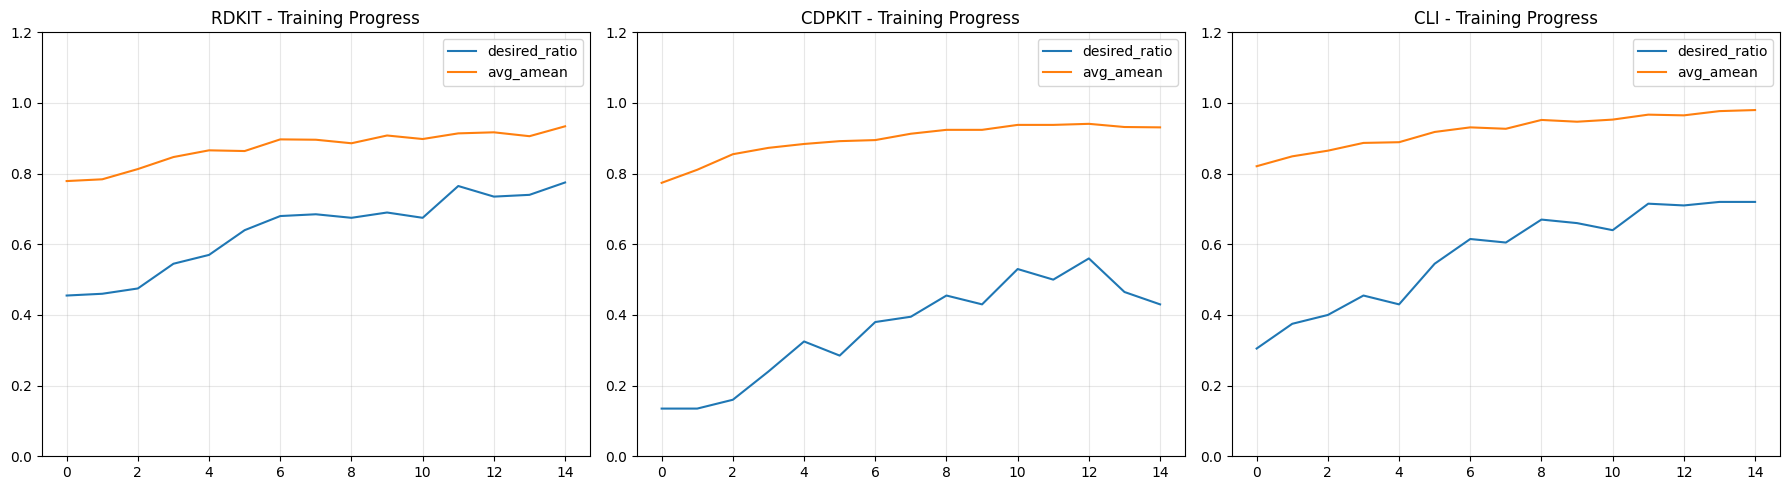

In [13]:
import matplotlib.pyplot as plt
from pathlib import Path

df_results = pd.DataFrame(rl_runs)

if df_results.empty:
    print('No reinforcement-learning runs recorded yet.')
else:
    available = df_results[df_results['fit_path'].apply(lambda p: Path(p).exists())]
    if available.empty:
        print('Training history files not found for the recorded runs.')
    else:
        fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
        if len(available) == 1:
            axes = [axes]

        for ax, row in zip(axes, available.itertuples()):
            df_rl = pd.read_csv(row.fit_path, sep='	')
            plot_cols = [col for col in ['desired_ratio', 'avg_amean'] if col in df_rl.columns]
            extra_cols = [col for col in df_rl.columns if col not in plot_cols + ['epoch']]
            while len(plot_cols) < 2 and extra_cols:
                plot_cols.append(extra_cols.pop(0))
            if 'epoch' in df_rl.columns:
                df_rl.plot(x='epoch', y=plot_cols, ax=ax, title=f"{row.backend.upper()} - Training Progress")
            else:
                df_rl[plot_cols].plot(ax=ax, title=f"{row.backend.upper()} - Training Progress")
            ax.set_ylim(0, 1.2)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


## Generating Optimized Molecules

Now we use the trained RL models to generate novel molecules that satisfy our objectives. We'll generate molecules from each backend and compare their scores.

In [13]:
# Generate molecules from trained RL models
backends = {'rdkit': env_rdkit, 'cdpkit': env_cdpkit, 'cli': env_cli}
results = []

for backend, env_builder in backends.items():
    checkpoint = RUN_DIR / f"{backend}_rl" / f"CCR2_{backend}_reinforced.pkg"
    
    if not checkpoint.exists():
        continue
    
    print(f"\n{'='*50}\n{backend.upper()} Model Generation\n{'='*50}")
    
    try:
        _, env = env_builder()
        agent = SequenceRNN(voc, is_lstm=True)
        agent.loadStatesFromFile(str(checkpoint))
        
        df_gen = agent.generate(num_samples=1000,batch_size=256, evaluator=env)
        scorer_keys = env.getScorerKeys()
        df_gen['Total'] = df_gen[scorer_keys].mean(axis=1)
        
        out_file = checkpoint.parent / f"CCR2_{backend}_reinforced_generated.tsv"
        df_gen.to_csv(out_file, sep='\t', index=False)
        
        desired_pct = df_gen.get('Desired', pd.Series([0])).mean() * 100
        print(f"Generated: {len(df_gen)} | Desired: {desired_pct:.1f}%")
        print(f"Scores: {df_gen[scorer_keys + ['Total']].mean().to_dict()}")
        
        results.append({'backend': backend, 'desired_pct': desired_pct, 'count': len(df_gen)})
    except Exception as e:
        print(f"Skipped {backend}: {e}")

if results:
    print(f"\n{'='*50}\nSummary\n{'='*50}")
    print(pd.DataFrame(results))


RDKIT Model Generation


Generating molecules:   0%|          | 0/1000 [00:00<?, ?it/s]

Scoring 242 molecules with ['RDKit_Aggregate_5refs_TanimotoCombo']...


CC(NC(=O)c1ccc(Cl)cc1)C12CC3CC(CC(C3)C1)C2: mol_133+0 failed conformer generation
CC(NC(=O)c1ccc(Cl)cc1)C12CC3CC(CC(C3)C1)C2: mol_133+1 failed conformer generation
Skipping Cc1ccc(S(=O)(=O)N(Cc2ccccc2)c2ccccc2C(=O)NCCc2ccc(O)cc2)cc1 with > 30 heavy atoms
Clc1ccc(C2(Cc3c(Cl)cccc3Cl)C3CC4CNCC(C3)C42)cc1: mol_159+0 failed conformer generation
Clc1ccc(C2(Cc3c(Cl)cccc3Cl)C3CC4CNCC(C3)C42)cc1: mol_159+1 failed conformer generation
Skipping COc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2C(=O)c2ccc(S(C)(=O)=O)cc2Br)cc1 with > 30 heavy atoms
Skipping COc1ccc(C(=O)c2cc(C(=O)c3cccnc3)c3cc(C)ccc3c2O[Si])cc1 with > 30 heavy atoms
Scoring unique molecules: 100%|██████████| 242/242 [00:01<00:00, 131.69it/s]


Scoring complete. Average score: 0.893, Max score: 1.534, Molecules with score > 0: 237/242
Scoring 231 molecules with ['RDKit_Aggregate_5refs_TanimotoCombo']...


...

Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  ROCS execution: 8.1s
ROCS scoring completed in 14.7s
Starting ROCS scoring for 221 molecules...
Generating conformers...


.. 100 molecules processed.
.. 200 molecules processed.

Total: 219 molecules processed.


Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  ROCS execution: 8.1s
ROCS scoring completed in 15.1s
Starting ROCS scoring for 1000 molecules...
Generating conformers...


. 100 molecules processed.
. 200 molecules processed.
. 300 molecules processed.
. 400 molecules processed.
.. 500 molecules processed.
. 600 molecules processed.
.. 700 molecules processed.
. 800 molecules processed.
. 900 molecules processed.

Total: 984 molecules processed.


Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  ROCS execution: 21.5s
ROCS scoring completed in 46.2s
Generated: 1000 | Desired: 73.9%
Scores: {'ROCS_CCR2': 0.962382972240448, 'SA': 1.947031, 'Total': 1.454707000067711}

Summary
  backend  desired_pct  count
0   rdkit         82.4   1000
1  cdpkit         50.9   1000
2     cli         73.9   1000
